In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os
os.chdir('/content/drive/MyDrive/proyecto/dataset/')
!pwd

/content/drive/MyDrive/proyecto/dataset


In [19]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive
import cv2

BASE_PATH = '/content/drive/MyDrive/proyecto/dataset/Concrete Crack Images for Classification'

POS_PATH = os.path.join(BASE_PATH, 'Positive')
NEG_PATH = os.path.join(BASE_PATH, 'Negative')



Total de imágenes con fisuras (Positive): 11667
Total de imágenes de concreto sano (Negative): 18583
Total del dataset: 30250 imágenes


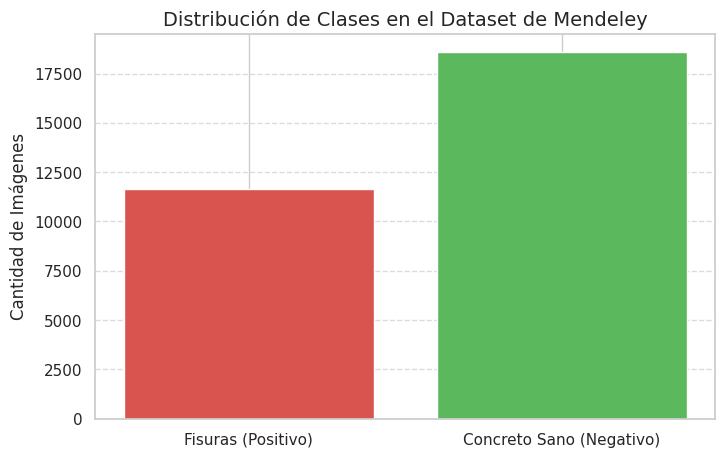

In [36]:

pos_images = [f for f in os.listdir(POS_PATH) if f.endswith('.jpg')]
neg_images = [f for f in os.listdir(NEG_PATH) if f.endswith('.jpg')]

num_pos = len(pos_images)
num_neg = len(neg_images)

print(f"Total de imágenes con fisuras (Positive): {num_pos}")
print(f"Total de imágenes de concreto sano (Negative): {num_neg}")
print(f"Total del dataset: {num_pos + num_neg} imágenes")

# Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(['Fisuras (Positivo)', 'Concreto Sano (Negativo)'], [num_pos, num_neg], color=['#d9534f', '#5cb85c'])
plt.title('Distribución de Clases en el Dataset de Mendeley', fontsize=14)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

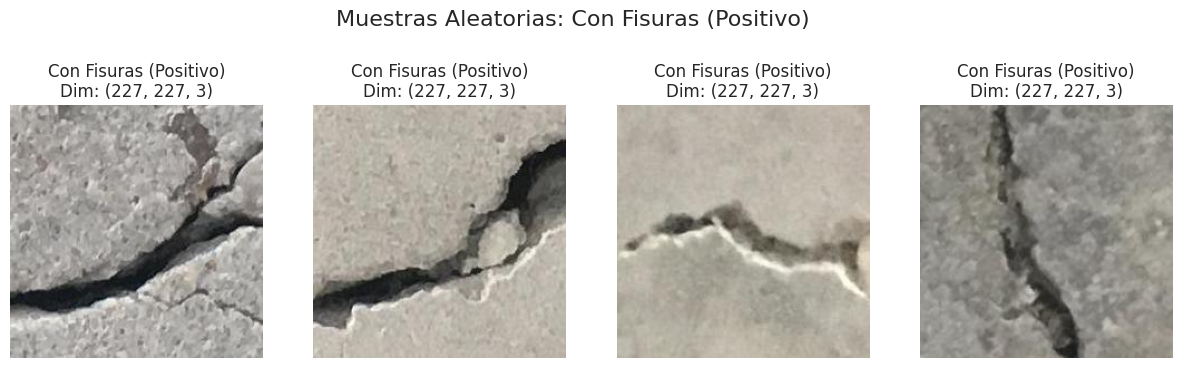

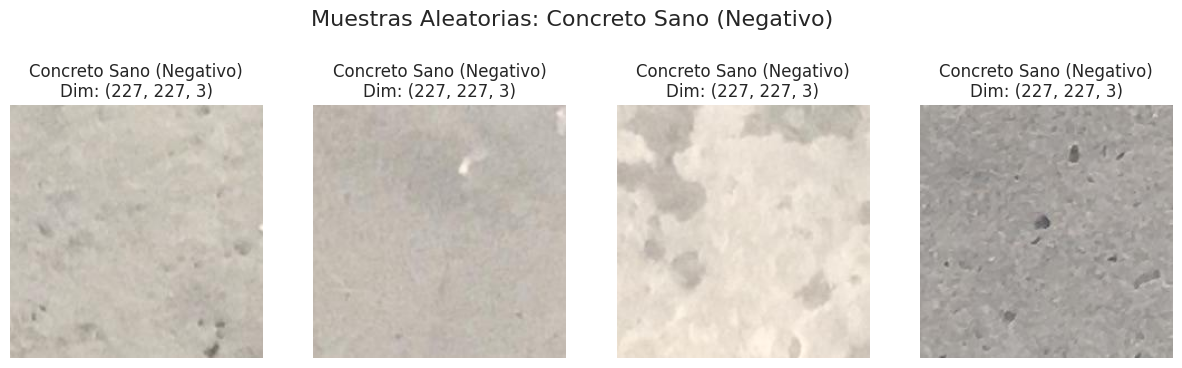

In [28]:
def plot_random_samples(path, class_name, num_samples=4):
    images = [f for f in os.listdir(path) if f.endswith('.jpg')]
    random_samples = random.sample(images, num_samples)

    plt.figure(figsize=(15, 4))
    for i, img_name in enumerate(random_samples):
        img_path = os.path.join(path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"{class_name}\nDim: {img.shape}")
        plt.axis('off')

    plt.suptitle(f"Muestras Aleatorias: {class_name}", fontsize=16, y=1.05)
    plt.show()

# Muestras
plot_random_samples(POS_PATH, 'Con Fisuras (Positivo)')
plot_random_samples(NEG_PATH, 'Concreto Sano (Negativo)')

Calculando intensidad de píxeles


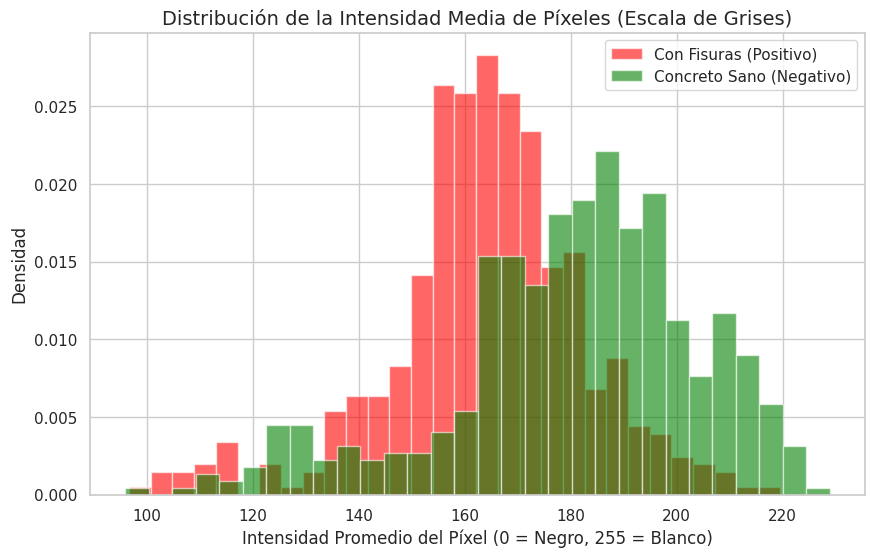

In [31]:
def analyze_pixel_intensity(path, num_samples=500):
    images = [f for f in os.listdir(path) if f.endswith('.jpg')]
    random_samples = random.sample(images, min(num_samples, len(images)))

    mean_intensities = []

    for img_name in random_samples:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mean_intensities.append(np.mean(img))

    return mean_intensities

print("Calculando intensidad de píxeles")
pos_intensities = analyze_pixel_intensity(POS_PATH)
neg_intensities = analyze_pixel_intensity(NEG_PATH)

# Histograma de densidades
plt.figure(figsize=(10, 6))
plt.hist(pos_intensities, bins=30, alpha=0.6, color='red', label='Con Fisuras', density=True)
plt.hist(neg_intensities, bins=30, alpha=0.6, color='green', label='Concreto Sano', density=True)
plt.title('Distribución de la Intensidad Media de Píxeles', fontsize=14)
plt.xlabel('Intensidad Promedio del Píxel (0 = Negro, 255 = Blanco)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [32]:
import os
import shutil
import random
from tqdm import tqdm


random.seed(42)

DRIVE_PATH = '/content/drive/MyDrive/proyecto/dataset/Concrete Crack Images for Classification'
LOCAL_BASE = '/content/dataset'

# plit
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

clases = ['Positive', 'Negative']
splits = ['train', 'val', 'test']

for split in splits:
    for cls in clases:
        os.makedirs(os.path.join(LOCAL_BASE, split, cls), exist_ok=True)

# Función para dividir y copiar archivos
def split_and_copy_data(cls_name):
    src_dir = os.path.join(DRIVE_PATH, cls_name)
    files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]

    # Mezclar archivos aleatoriamente
    random.shuffle(files)

    # Calcular índices
    train_idx = int(len(files) * TRAIN_RATIO)
    val_idx = train_idx + int(len(files) * VAL_RATIO)

    # Dividir listas
    train_files = files[:train_idx]
    val_files = files[train_idx:val_idx]
    test_files = files[val_idx:]

    # Función auxiliar para copiar
    def copy_files(file_list, split_name):
        dest_dir = os.path.join(LOCAL_BASE, split_name, cls_name)
        for f in tqdm(file_list, desc=f"Copiando {split_name} - {cls_name}"):
            shutil.copy(os.path.join(src_dir, f), os.path.join(dest_dir, f))

    # Ejecutar copiado
    copy_files(train_files, 'train')
    copy_files(val_files, 'val')
    copy_files(test_files, 'test')

# Ejecutar el proceso
print("Iniciando la transferencia al disco de alto rendimiento de Colab")
split_and_copy_data('Positive')
split_and_copy_data('Negative')
print("\n¡División y transferencia completada con éxito!")

Iniciando la transferencia al disco de alto rendimiento de Colab


Copiando test - Negative: 100%|██████████| 1859/1859 [00:03<00:00, 488.12it/s]


¡División y transferencia completada con éxito!


In [33]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Variación de luz
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


test_val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


train_dataset = datasets.ImageFolder(os.path.join(LOCAL_BASE, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(LOCAL_BASE, 'val'), transform=test_val_transforms)
test_dataset = datasets.ImageFolder(os.path.join(LOCAL_BASE, 'test'), transform=test_val_transforms)


BATCH_SIZE = 32 # Tamaño de lote ideal para GPUs como T4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Clases detectadas: {train_dataset.classes}")
print(f"Lotes de entrenamiento: {len(train_loader)} (x {BATCH_SIZE} imágenes)")
print(f"Lotes de validación: {len(val_loader)}")
print(f"Lotes de prueba: {len(test_loader)}")

Clases detectadas: ['Negative', 'Positive']
Lotes de entrenamiento: 753 (x 32 imágenes)
Lotes de validación: 99
Lotes de prueba: 99
